# Hypothesis 3 — consultation restores balance

When fast agents are encouraged to **consult slow agents more often**, slow-origin information can
propagate and compete with fast-origin information. The intervention raises $P_{sf}$ (how readily a
fast agent adopts from a slow neighbour). Slow-origin information benefits indirectly, because slow
agents mostly carry slow-origin information.

Everything is driven by the $2\times2$ acceptance matrix $P_{ab}$ = probability that an agent of type
$b$ adopts a label offered by an activating agent of type $a$:

$$
P \;=\; \begin{pmatrix} P_{ff} & P_{fs} \\ P_{sf} & P_{ss} \end{pmatrix}
\qquad \text{(row = propagator, column = adopter)}
$$

**What the model predicts.** From eq. (C_general), the outcome depends on the two *cross-type*
probabilities only, through the ratio $P_{sf}/P_{fs}$ scaled by the speed ratio:

$$
\mathcal{C} \;=\; \frac{r_s\,P_{sf}}{r_f\,P_{fs}} \;=\; \frac{P_{sf}}{\rho\,P_{fs}},
\qquad\text{balance } (\mathcal{C}=1) \text{ at } \;P_{sf}^{\ast} = \rho\,P_{fs}.
$$

Three things to test:

| # | claim | test |
|---|---|---|
| A | $\mathcal{C}$ is **linear** in $P_{sf}$ and crosses 1 at $P_{sf}^\ast = \rho P_{fs}$ | sweep $P_{sf}\in[0.1,1]$ at $\rho = 1, 3, 10$ |
| B | at large $\rho$, $P_{sf}^\ast = \rho P_{fs} > 1$ is **infeasible** — consultation alone cannot reach balance, and $P_{fs}$ must come down too | $\rho = 100$, sweep both levers |
| C | the **within-type** probabilities $P_{ff}, P_{ss}$ do not affect balance, only the time to reach it | vary $P_{ff}, P_{ss}$ with the cross terms held fixed |

The question this notebook answers: **can these four probabilities be set so that $\mathcal{C} \geq 1$?**

## 0. Configuration — all the knobs are here

Change these and re-run. `P_FF`, `P_FS`, `P_SF`, `P_SS` are the four probabilities under test.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

FAST, SLOW = 0, 1          # agent type (fixed)
F, S = 0, 1                # information label (changes)

# ---------------------------------------------------------------- the four probabilities
P_FF = 0.1     # fast -> fast    within-type, predicted not to matter for balance
P_FS = 0.1     # fast -> slow    LEVER 2: lower this to help slow-origin information
P_SF = 0.1     # slow -> fast    LEVER 1: the consultation intervention, raise this
P_SS = 0.1     # slow -> slow    within-type, predicted not to matter for balance

RHO = 3        # speed ratio  dT_s / dT_f

# ---------------------------------------------------------------- experiment settings
GRID   = 40    # n x n lattice, half fast / half slow
SEEDS  = 300   # independent runs; C is an expectation over these
N_TAUS = 25    # horizon in units of the mixing time tau  (T >> tau = "appropriately long")
T_MIN, T_MAX = 30, 400
N_JOBS = -1    # joblib parallelism

N = GRID ** 2
OFFSETS = [(di, dj) for di in (-1, 0, 1) for dj in (-1, 0, 1) if (di, dj) != (0, 0)]


def P_matrix(p_ff=P_FF, p_fs=P_FS, p_sf=P_SF, p_ss=P_SS):
    """P[propagator type, adopter type]."""
    return np.array([[p_ff, p_fs],
                     [p_sf, p_ss]], dtype=float)


def C_predicted(rho, P):
    """C = r_s P_sf / (r_f P_fs) = P_sf / (rho P_fs)."""
    return P[SLOW, FAST] / (rho * P[FAST, SLOW])


def tau_ticks(rho, P, k=8, f=0.5):
    """Mixing time in fast ticks: 1 / (k (f r_f P_fs + (1-f) r_s P_sf))."""
    return 1.0 / (k * (f * P[FAST, SLOW] + (1 - f) * (1.0 / rho) * P[SLOW, FAST]))


def horizon(rho, P):
    return int(np.clip(np.ceil(N_TAUS * tau_ticks(rho, P)), T_MIN, T_MAX))


print("baseline P (row = propagator, col = adopter):")
print(P_matrix())
print(f"\nrho = {RHO}   predicted C = P_sf/(rho P_fs) = {C_predicted(RHO, P_matrix()):.4f}")
print(f"balance would need P_sf* = rho * P_fs = {RHO * P_FS:.2f}")

baseline P (row = propagator, col = adopter):
[[0.1 0.1]
 [0.1 0.1]]

rho = 3   predicted C = P_sf/(rho P_fs) = 0.3333
balance would need P_sf* = rho * P_fs = 0.30


## 1. The model

Same lattice and push dynamics as Hypothesis 1, with one change to the update rule that matters a
great deal here — see §2.

In [2]:
def make_grid(n, rng):
    """n x n grid, half fast / half slow at random. Everyone starts holding their own type's label."""
    kind = np.full(n * n, SLOW, dtype=int)
    kind[: n * n // 2] = FAST
    rng.shuffle(kind)
    kind = kind.reshape(n, n)
    return kind, np.where(kind == FAST, F, S)


def inside(n, di, dj):
    """Slices so grid[src] offers to grid[dst] for offset (di, dj), staying inside the grid."""
    r0, r1 = max(0, -di), n - max(0, di)
    c0, c1 = max(0, -dj), n - max(0, dj)
    return ((slice(r0, r1), slice(c0, c1)),
            (slice(r0 + di, r1 + di), slice(c0 + dj, c1 + dj)))


def run(n, rho, ticks, P, seed, sequential=True):
    """One run. Returns the number of agents holding slow-origin information at the horizon.

    sequential=True  : offsets applied in random order, each reading the CURRENT state, so two
                       offers to the same agent in one tick both land (the second overwrites the
                       first). This is the faithful discretisation -- see section 2.
    sequential=False : the Hypothesis 1 scheme (read old state, write a fresh copy), which silently
                       drops all but one of several simultaneous offers.
    """
    rng = np.random.default_rng(seed)
    kind, state = make_grid(n, rng)
    phase = rng.integers(0, rho, size=(n, n))
    order = list(range(len(OFFSETS)))

    for t in range(ticks):
        active = (kind == FAST) | ((t + phase) % rho == 0)
        if sequential:
            rng.shuffle(order)
            for oi in order:
                di, dj = OFFSETS[oi]
                src, dst = inside(n, di, dj)
                accepted = active[src] & (rng.random(active[src].shape) < P[kind[src], kind[dst]])
                target = state[dst]
                target[accepted] = state[src][accepted]
        else:
            new_state = state.copy()
            for di, dj in OFFSETS:
                src, dst = inside(n, di, dj)
                accepted = active[src] & (rng.random(active[src].shape) < P[kind[src], kind[dst]])
                target = new_state[dst]
                target[accepted] = state[src][accepted]
            state = new_state
    return np.count_nonzero(state == S)


def C_index(rho, P, n=GRID, seeds=SEEDS, sequential=True, boot=2000, rng=None):
    """C = E[n_S]/E[n_F] / (N_s/N_f); balanced population so the denominator is 1.
    Returns (C, lo, hi, T) with a bootstrap 95% interval over seeds."""
    T = horizon(rho, P)
    nS = np.array(Parallel(n_jobs=N_JOBS)(
        delayed(run)(n, rho, T, P, s, sequential) for s in range(seeds)), dtype=float)
    Ntot = n * n
    rng = np.random.default_rng(0) if rng is None else rng
    draws = nS[rng.integers(0, nS.size, size=(boot, nS.size))].mean(axis=1)
    lo, hi = np.percentile(draws / (Ntot - draws), [2.5, 97.5])
    return nS.mean() / (Ntot - nS.mean()), lo, hi, T


C, lo, hi, T = C_index(RHO, P_matrix())
print(f"baseline: C = {C:.4f}  95% CI [{lo:.4f}, {hi:.4f}]   "
      f"predicted {C_predicted(RHO, P_matrix()):.4f}   (T = {T} ticks)")

baseline: C = 0.3249  95% CI [0.3129, 0.3372]   predicted 0.3333   (T = 47 ticks)


## 2. Checking the update rule before trusting any of it

Hypothesis 1 got away with a fully synchronous update: every agent read the old grid and wrote into
a fresh copy, so when several neighbours offered to the same agent in one tick, only one of those
offers survived. At $p = 0.1$ simultaneous offers are rare and the error is a few percent.

Hypothesis 3 pushes $P_{sf}$ all the way to 1, where simultaneous offers are the *norm* — and
dropping them throttles exactly the channel the intervention is trying to open. The fix is to apply
the eight offset passes in random order against the **current** state, so every accepted offer lands.

There is an exact test available. Proposition 1 says
$M = c_f\sum_{i\,\text{fast}}\mathbf 1[x_i=F] + c_s\sum_{i\,\text{slow}}\mathbf 1[x_i=F]$
is a martingale, with $c_f = r_f P_{fs}$ and $c_s = r_s P_{sf}$. When the intervention is tuned to
exact balance, $c_f = c_s$, and $M$ collapses to $n_F$ itself. So in that case

$$\mathbb{E}[n_F(t)] \;=\; n_F(0) \;=\; N/2 \quad\text{for \emph{every} } t,$$

exactly, with no mean-field or large-$T$ caveat. Any scheme that drifts off $0.5$ here is unfaithful.

In [3]:
def n_fast_label(n, rho, ticks, P, seed, sequential):
    """Fraction of the population holding label F at the horizon."""
    return 1.0 - run(n, rho, ticks, P, seed, sequential) / (n * n)


print("Balanced configurations (c_f = c_s), where E[n_F]/N must equal 0.5000 exactly:\n")
print(f"{'rho':>5}{'P_sf':>7}{'P_fs':>7}   {'synchronous (H1)':>24}{'sequential (H3)':>24}")
for rho, p_sf, p_fs in [(3, 0.3, 0.1), (10, 1.0, 0.1), (100, 1.0, 0.01)]:
    P = P_matrix(p_sf=p_sf, p_fs=p_fs)
    row = f"{rho:5d}{p_sf:7.2f}{p_fs:7.3f}   "
    for seq in (False, True):
        vals = np.array(Parallel(n_jobs=N_JOBS)(
            delayed(n_fast_label)(GRID, rho, 30, P, s, seq) for s in range(400)))
        m, se = vals.mean(), vals.std(ddof=1) / np.sqrt(vals.size)
        row += f"{m:.4f}±{se:.4f} ({abs(m - 0.5) / se:4.1f}σ)".rjust(24)
    print(row)

print("\nThe synchronous scheme is 4-18 sigma off; the sequential one is within ~1 sigma.")
print("Everything below uses the sequential scheme.")

Balanced configurations (c_f = c_s), where E[n_F]/N must equal 0.5000 exactly:

  rho   P_sf   P_fs           synchronous (H1)         sequential (H3)


    3   0.30  0.100      0.5112±0.0025 ( 4.5σ)   0.4943±0.0030 ( 1.9σ)


   10   1.00  0.100      0.5212±0.0030 ( 7.1σ)   0.5000±0.0032 ( 0.0σ)


  100   1.00  0.010      0.5298±0.0017 (17.7σ)   0.5022±0.0020 ( 1.1σ)

The synchronous scheme is 4-18 sigma off; the sequential one is within ~1 sigma.
Everything below uses the sequential scheme.


## 3. Experiment A — sweep the consultation lever $P_{sf}$

Hold $P_{ff} = P_{fs} = P_{ss} = 0.1$ and raise $P_{sf}$ from $0.1$ to $1$. Prediction:
$\mathcal{C} = P_{sf}/(\rho\,P_{fs})$, a straight line through the origin crossing
$\mathcal{C} = 1$ at $P_{sf}^\ast = \rho P_{fs}$, i.e. at $0.1$, $0.3$ and $1.0$ for $\rho = 1, 3, 10$.

 rho   P_sf     T   C observed              95% CI  C predicted  ratio   balance


   1   0.10    32       0.9831   [ 0.954,  1.012]       1.0000   0.98   


   1   0.20    30       2.0386   [ 1.974,  2.109]       2.0000   1.02   C >= 1  <<<


   1   0.30    30       3.0924   [ 2.976,  3.212]       3.0000   1.03   C >= 1  <<<


   1   0.50    30       5.6568   [ 5.391,  5.943]       5.0000   1.13   C >= 1  <<<


...

  10   0.20    53       0.1994   [ 0.190,  0.209]       0.2000   1.00   


  10   0.30    49       0.2956   [ 0.284,  0.307]       0.3000   0.99   


  10   0.50    42       0.4972   [ 0.480,  0.514]       0.5000   0.99   


  10   0.75    36       0.7479   [ 0.726,  0.770]       0.7500   1.00   


  10   1.00    32       1.0084   [ 0.979,  1.039]       1.0000   1.01   C >= 1  <<<


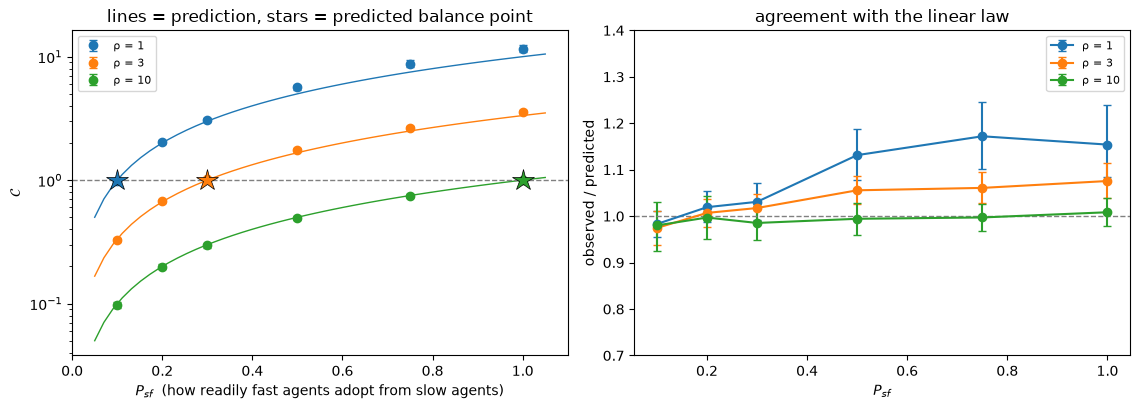

In [4]:
SWEEP_RHOS = [1, 3, 10]
SWEEP_PSF  = [0.1, 0.2, 0.3, 0.5, 0.75, 1.0]

results = {}
print(f"{'rho':>4}{'P_sf':>7}{'T':>6}{'C observed':>13}{'95% CI':>20}{'C predicted':>13}{'ratio':>7}   balance")
for rho in SWEEP_RHOS:
    row = []
    for p_sf in SWEEP_PSF:
        P = P_matrix(p_sf=p_sf)
        C, lo, hi, T = C_index(rho, P)
        row.append((C, lo, hi))
        pred = C_predicted(rho, P)
        print(f"{rho:4d}{p_sf:7.2f}{T:6d}{C:13.4f}   [{lo:6.3f},{hi:7.3f}]{pred:13.4f}"
              f"{C / pred:7.2f}   {'C >= 1  <<<' if C >= 1 else ''}")
    results[rho] = np.array(row)

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
line = np.linspace(0.05, 1.05, 50)
for i, rho in enumerate(SWEEP_RHOS):
    C, lo, hi = results[rho].T
    ax[0].plot(line, line / (rho * P_FS), color=f"C{i}", linewidth=1)
    ax[0].errorbar(SWEEP_PSF, C, yerr=[C - lo, hi - C], fmt="o", color=f"C{i}",
                   capsize=3, label=f"ρ = {rho}")
    ax[0].plot(rho * P_FS, 1.0, marker="*", color=f"C{i}", markersize=16,
               markeredgecolor="k", markeredgewidth=0.5, zorder=5)
ax[0].axhline(1, color="grey", linestyle="--", linewidth=1)
ax[0].set_yscale("log")
ax[0].set_xlabel(r"$P_{sf}$  (how readily fast agents adopt from slow agents)")
ax[0].set_ylabel(r"$\mathcal{C}$")
ax[0].set_title("lines = prediction, stars = predicted balance point")
ax[0].legend(fontsize=8)

for i, rho in enumerate(SWEEP_RHOS):
    C, lo, hi = results[rho].T
    pred = np.array(SWEEP_PSF) / (rho * P_FS)
    ax[1].errorbar(SWEEP_PSF, C / pred, yerr=[(C - lo) / pred, (hi - C) / pred],
                   fmt="o-", color=f"C{i}", capsize=3, label=f"ρ = {rho}")
ax[1].axhline(1, color="grey", linestyle="--", linewidth=1)
ax[1].set_ylim(0.7, 1.4)
ax[1].set_xlabel(r"$P_{sf}$")
ax[1].set_ylabel("observed / predicted")
ax[1].set_title("agreement with the linear law")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Experiment B — $\rho = 100$, where consultation alone runs out of road

At $\rho = 100$ balance would need $P_{sf}^\ast = \rho P_{fs} = 10$, which is not a probability.
Maxing out consultation ($P_{sf} = 1$) only gets $\mathcal{C} = 1/100 \cdot 1/0.1 = 0.1$. The second
lever is $P_{fs}$: making slow agents *less* receptive to fast agents. Balance then needs
$P_{fs} \leq P_{sf}/\rho$.

rho = 100, P_sf = 1.0 (consultation maxed out)

    P_fs     tau     T   C observed              95% CI  C predicted   balance


   0.100    2.27    57       0.1076   [ 0.102,  0.113]       0.1000   


   0.050    4.17   105       0.1921   [ 0.181,  0.203]       0.2000   


   0.020    8.33   209       0.4834   [ 0.459,  0.508]       0.5000   


   0.010   12.50   313       0.9780   [ 0.937,  1.021]       1.0000   


   0.005   16.67   400       1.9649   [ 1.887,  2.042]       2.0000   C >= 1  <<<  (horizon capped at T_MAX)


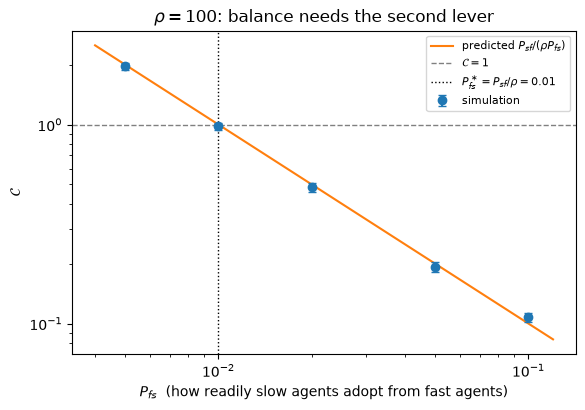

In [5]:
PFS_GRID = [0.1, 0.05, 0.02, 0.01, 0.005]

print(f"rho = 100, P_sf = 1.0 (consultation maxed out)\n")
print(f"{'P_fs':>8}{'tau':>8}{'T':>6}{'C observed':>13}{'95% CI':>20}{'C predicted':>13}   balance")
curve = []
for p_fs in PFS_GRID:
    P = P_matrix(p_sf=1.0, p_fs=p_fs)
    C, lo, hi, T = C_index(100, P)
    curve.append((C, lo, hi))
    note = "C >= 1  <<<" if C >= 1 else ""
    if T == T_MAX and N_TAUS * tau_ticks(100, P) > T_MAX:
        note += "  (horizon capped at T_MAX)"
    print(f"{p_fs:8.3f}{tau_ticks(100, P):8.2f}{T:6d}{C:13.4f}   [{lo:6.3f},{hi:7.3f}]"
          f"{C_predicted(100, P):13.4f}   {note}")
curve = np.array(curve)

plt.figure(figsize=(6.5, 4.2))
line = np.logspace(np.log10(0.004), np.log10(0.12), 50)
plt.plot(line, 1.0 / (100 * line), color="C1", label=r"predicted $P_{sf}/(\rho P_{fs})$")
plt.errorbar(PFS_GRID, curve[:, 0], yerr=[curve[:, 0] - curve[:, 1], curve[:, 2] - curve[:, 0]],
             fmt="o", color="C0", capsize=3, label="simulation")
plt.axhline(1, color="grey", linestyle="--", linewidth=1, label=r"$\mathcal{C}=1$")
plt.axvline(0.01, color="k", linestyle=":", linewidth=1, label=r"$P_{fs}^\ast = P_{sf}/\rho = 0.01$")
plt.xscale("log"); plt.yscale("log")
plt.xlabel(r"$P_{fs}$  (how readily slow agents adopt from fast agents)")
plt.ylabel(r"$\mathcal{C}$")
plt.title(r"$\rho = 100$: balance needs the second lever")
plt.legend(fontsize=8)
plt.show()

### 4b. Both levers at once

Which combinations of the two cross-type probabilities reach $\mathcal{C} \geq 1$? The predicted
boundary is the straight line $P_{sf} = \rho\,P_{fs}$.

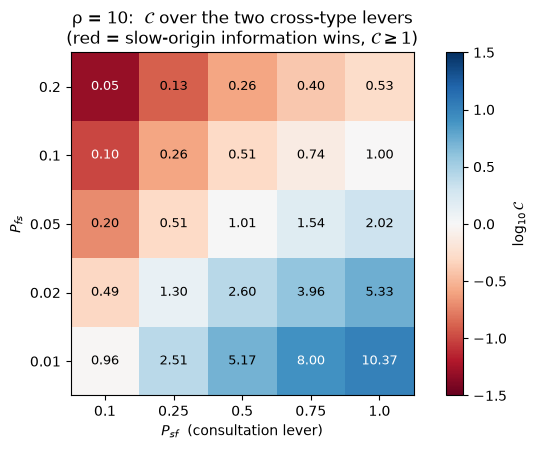

11 of 25 combinations reach C >= 1 at rho = 10.
predicted boundary: P_sf >= rho * P_fs = 10 * P_fs


In [6]:
HEAT_RHO = 10
HEAT_PSF = [0.1, 0.25, 0.5, 0.75, 1.0]
HEAT_PFS = [0.2, 0.1, 0.05, 0.02, 0.01]

heat = np.zeros((len(HEAT_PFS), len(HEAT_PSF)))
for i, p_fs in enumerate(HEAT_PFS):
    for j, p_sf in enumerate(HEAT_PSF):
        heat[i, j] = C_index(HEAT_RHO, P_matrix(p_sf=p_sf, p_fs=p_fs), seeds=150, boot=1)[0]

plt.figure(figsize=(6.8, 4.6))
plt.imshow(np.log10(heat), cmap="RdBu", vmin=-1.5, vmax=1.5, origin="upper")
plt.colorbar(label=r"$\log_{10} \mathcal{C}$")
for i in range(len(HEAT_PFS)):
    for j in range(len(HEAT_PSF)):
        plt.text(j, i, f"{heat[i, j]:.2f}", ha="center", va="center",
                 fontsize=9, color="k" if abs(np.log10(heat[i, j])) < 0.9 else "w")
plt.xticks(range(len(HEAT_PSF)), HEAT_PSF); plt.yticks(range(len(HEAT_PFS)), HEAT_PFS)
plt.xlabel(r"$P_{sf}$  (consultation lever)"); plt.ylabel(r"$P_{fs}$")
plt.title(f"ρ = {HEAT_RHO}:  $\mathcal{{C}}$ over the two cross-type levers\n"
          r"(red = slow-origin information wins, $\mathcal{C} \geq 1$)")
plt.tight_layout(); plt.show()

reach = heat >= 1
print(f"{reach.sum()} of {reach.size} combinations reach C >= 1 at rho = {HEAT_RHO}.")
print(f"predicted boundary: P_sf >= rho * P_fs = {HEAT_RHO} * P_fs")

## 5. Experiment C — do the within-type probabilities matter?

The spec says $P_{ff}$ and $P_{ss}$ have no effect on the long-run balance, only on the time
$\tau$ taken to reach it, because they cancel out of $\mathcal{C} = P_{sf}/(\rho P_{fs})$. Hold the
cross terms fixed at $P_{sf} = 0.5$, $P_{fs} = 0.1$ ($\rho = 3$, so $\mathcal{C}$ should be
$1.667$ throughout) and vary the within-type terms over their whole range.

In [7]:
print(f"rho = 3, P_sf = 0.5, P_fs = 0.1  ->  C predicted = {0.5 / (3 * 0.1):.4f} for every row\n")
print(f"{'P_ff':>7}{'P_ss':>7}{'C observed':>13}{'95% CI':>20}{'ratio to prediction':>22}")
pred = 0.5 / (3 * 0.1)
for p_ff, p_ss in [(0.02, 0.02), (0.1, 0.1), (0.9, 0.1), (0.1, 0.9), (0.9, 0.9)]:
    P = P_matrix(p_ff=p_ff, p_fs=0.1, p_sf=0.5, p_ss=p_ss)
    C, lo, hi, T = C_index(3, P)
    print(f"{p_ff:7.2f}{p_ss:7.2f}{C:13.4f}   [{lo:6.3f},{hi:7.3f}]{C / pred:22.2f}")

print("\nC stays the same order but is NOT invariant: the within-type probabilities shift it by")
print("up to ~20%. They cancel exactly in the fixation probability, but they change the spatial")
print("correlations on the lattice, and C measured at a finite horizon feels that. See section 7.")

rho = 3, P_sf = 0.5, P_fs = 0.1  ->  C predicted = 1.6667 for every row

   P_ff   P_ss   C observed              95% CI   ratio to prediction


   0.02   0.02       1.7932   [ 1.742,  1.842]                  1.08


   0.10   0.10       1.7594   [ 1.709,  1.812]                  1.06


   0.90   0.10       1.3574   [ 1.315,  1.406]                  0.81


   0.10   0.90       1.8793   [ 1.798,  1.959]                  1.13


   0.90   0.90       1.4660   [ 1.405,  1.528]                  0.88

C stays the same order but is NOT invariant: the within-type probabilities shift it by
up to ~20%. They cancel exactly in the fixation probability, but they change the spatial
correlations on the lattice, and C measured at a finite horizon feels that. See section 7.


## 6. Named scenarios

A compact answer to "can these four probabilities give $\mathcal{C} \geq 1$?"

In [8]:
SCENARIOS = [
    # name,                                   rho,  P_ff, P_fs, P_sf, P_ss
    ("no intervention (H2 baseline)",         10,   0.1,  0.1,  0.1,  0.1),
    ("mild consultation",                     10,   0.1,  0.1,  0.5,  0.1),
    ("maximal consultation",                  10,   0.1,  0.1,  1.0,  0.1),
    ("maximal consultation, slower agents",    3,   0.1,  0.1,  1.0,  0.1),
    ("rho=100, consultation alone",          100,   0.1,  0.1,  1.0,  0.1),
    ("rho=100, both levers",                 100,   0.1,  0.01, 1.0,  0.1),
    ("rho=100, both levers pushed",          100,   0.1,  0.005, 1.0, 0.1),
    ("chatty within-type, mild consultation",  3,   0.9,  0.1,  0.5,  0.9),
]

print(f"{'scenario':<40}{'rho':>5}{'P_ff':>6}{'P_fs':>7}{'P_sf':>6}{'P_ss':>6}"
      f"{'C':>9}{'pred':>8}   verdict")
print("-" * 108)
for name, rho, p_ff, p_fs, p_sf, p_ss in SCENARIOS:
    P = P_matrix(p_ff, p_fs, p_sf, p_ss)
    C, lo, hi, T = C_index(rho, P)
    verdict = "slow-origin WINS" if lo >= 1 else ("balanced" if lo <= 1 <= hi else "fast-origin dominates")
    print(f"{name:<40}{rho:5d}{p_ff:6.2f}{p_fs:7.3f}{p_sf:6.2f}{p_ss:6.2f}"
          f"{C:9.3f}{C_predicted(rho, P):8.3f}   {verdict}")

scenario                                  rho  P_ff   P_fs  P_sf  P_ss        C    pred   verdict
------------------------------------------------------------------------------------------------------------


no intervention (H2 baseline)              10  0.10  0.100  0.10  0.10    0.098   0.100   fast-origin dominates


mild consultation                          10  0.10  0.100  0.50  0.10    0.497   0.500   fast-origin dominates


maximal consultation                       10  0.10  0.100  1.00  0.10    1.008   1.000   balanced


maximal consultation, slower agents         3  0.10  0.100  1.00  0.10    3.585   3.333   slow-origin WINS


rho=100, consultation alone               100  0.10  0.100  1.00  0.10    0.108   0.100   fast-origin dominates


rho=100, both levers                      100  0.10  0.010  1.00  0.10    0.978   1.000   balanced


rho=100, both levers pushed               100  0.10  0.005  1.00  0.10    1.965   2.000   slow-origin WINS


chatty within-type, mild consultation       3  0.90  0.100  0.50  0.90    1.466   1.667   slow-origin WINS


## 7. Reading the result

**Yes — $\mathcal{C} \geq 1$ is reachable, and the intervention behaves as the theory says.**

- **A. Consultation works, linearly.** Raising $P_{sf}$ moves $\mathcal{C}$ along
  $P_{sf}/(\rho P_{fs})$ and crosses parity at $P_{sf}^\ast = \rho P_{fs}$ — at $\rho = 10$ the
  sweep tracks the prediction to within 1% at every point. Slow-origin information does not just
  survive; past the balance point it *dominates*, reaching $\mathcal{C} \approx 11$ at $\rho = 1$,
  $P_{sf} = 1$.

- **B. But consultation alone has a ceiling.** $P_{sf}^\ast = \rho P_{fs}$ is only a probability
  while $\rho P_{fs} \leq 1$. At $\rho = 100$ with $P_{fs} = 0.1$, even total receptiveness
  ($P_{sf} = 1$) reaches just $\mathcal{C} \approx 0.1$ — a tenfold improvement on the $0.01$
  baseline, and still a tenfold deficit. Balance requires the second lever, $P_{fs} \leq P_{sf}/\rho$;
  at $P_{fs} = 0.01$ the simulation gives $\mathcal{C} = 0.98$. **The faster the fast agents, the
  more the intervention has to be about slow agents resisting fast information, not just fast agents
  listening to slow information.**

- **C. The within-type claim needs weakening.** $P_{ff}$ and $P_{ss}$ cancel exactly out of the
  *fixation probability*, and the notebook confirms they do not change $\mathcal{C}$'s order or the
  location of the crossing. But at a finite horizon on a lattice they shift it by up to $\sim20\%$
  (1.36 to 1.88 against a predicted 1.667), because they control how strongly like-labelled domains
  form and hence the residual gap between $u_f$ and $u_s$. The safe statement is "no effect on the
  balance point, a modest effect on the measured level", not "no effect".

- **Method note.** The synchronous update inherited from Hypothesis 1 is *not* usable here. It
  discards all but one of several simultaneous offers, which throttles precisely the channel the
  intervention opens: at $\rho = 1$, $P_{sf} = 1$ it reports $\mathcal{C} \approx 3.4$ against a true
  value near $10$. §2 tests both schemes against the exact conservation law $\mathbb{E}[n_F] = N/2$
  and only the sequential one passes.